In [4]:
## module cubicSpline
''' k = curvatures(xData,yData).
    Returns the curvatures of cubic spline at its knots.

    y = evalSpline(xData,yData,k,x).
    Evaluates cubic spline at x. The curvatures k can be
    computed with the function 'curvatures'.
'''

Eval = [10,30,60,90]
import numpy as np

##LU DECOMP 3 AS A PREREQ
#######################################
def LUdecomp3(c,d,e):
    n = len(d)
    for k in range(1,n):
        lam = c[k-1]/d[k-1]
        d[k] = d[k] - lam*e[k-1]
        c[k-1] = lam
    return c,d,e

def LUsolve3(c,d,e,b):
    n = len(d)
    for k in range(1,n):
        b[k] = b[k] - c[k-1]*b[k-1]
    b[n-1] = b[n-1]/d[n-1]
    for k in range(n-2,-1,-1):
        b[k] = (b[k] - e[k]*b[k+1])/d[k]
    return b
###########################################
##CUBIC SPLINE CODE

def curvatures(xData, yData):
    n = len(xData) - 1
    c = np.zeros(n)
    d = np.ones(n + 1)
    e = np.zeros(n)
    k = np.zeros(n + 1)
    c[0:n - 1] = xData[0:n - 1] - xData[1:n]
    d[1:n] = 2.0 * (xData[0:n - 1] - xData[2:n + 1])
    e[1:n] = xData[1:n] - xData[2:n + 1]
    k[1:n] = 6.0 * (yData[0:n - 1] - yData[1:n]) \
             / (xData[0:n - 1] - xData[1:n]) \
             - 6.0 * (yData[1:n] - yData[2:n + 1]) \
             / (xData[1:n] - xData[2:n + 1])
    LUdecomp3(c, d, e)
    LUsolve3(c, d, e, k)
    return k


def evalSpline(xData, yData, k, x):
    def findSegment(xData, x):
        iLeft = 0
        iRight = len(xData) - 1
        while 1:
            if (iRight - iLeft) <= 1: return iLeft
            i = (iLeft + iRight) // 2
            if x < xData[i]:
                iRight = i
            else:
                iLeft = i

    i = findSegment(xData, x)
    h = xData[i] - xData[i + 1]
    y = ((x - xData[i + 1]) ** 3 / h - (x - xData[i + 1]) * h) * k[i] / 6.0 \
        - ((x - xData[i]) ** 3 / h - (x - xData[i]) * h) * k[i + 1] / 6.0 \
        + (yData[i] * (x - xData[i + 1]) \
           - yData[i + 1] * (x - xData[i])) / h
    return y

xData = np.array([0,21.1,37.8,54.4,71.1,87.8,100])
yData = np.array([0.00179, 0.00113, 0.000696,0.000519,0.000338,0.000321, 0.000269])
spline_interp = []
k = curvatures(xData,yData)
for i in Eval:
    mu = evalSpline(xData,yData,k,i)
    print(f'Cubic Spline at {i} C = {mu} m^2/s')
    spline_interp.append(mu)

# --- Gauss Elimination ---
def gaussElimin(a, b):
    n = len(b)
    for k in range(0, n-1):
        for i in range(k+1, n):
            if a[i,k] != 0.0:
                lam = a[i,k] / a[k,k]
                a[i,k+1:n] = a[i,k+1:n] - lam*a[k,k+1:n]
                b[i] = b[i] - lam*b[k]
    for k in range(n-1, -1, -1):
        b[k] = (b[k] - np.dot(a[k,k+1:n], b[k+1:n])) / a[k,k]
    return b

# --- LU Decomp for Spline ---
def LUdecomp3(c, d, e):
    n = len(d)
    for k in range(1, n):
        lam = c[k-1] / d[k-1]
        d[k] = d[k] - lam*e[k-1]
        c[k-1] = lam
    return c, d, e

def LUsolve3(c, d, e, b):
    n = len(d)
    for k in range(1, n):
        b[k] = b[k] - c[k-1]*b[k-1]
    b[n-1] = b[n-1] / d[n-1]
    for k in range(n-2, -1, -1):
        b[k] = (b[k] - e[k]*b[k+1]) / d[k]
    return b

# --- Cubic Spline ---
def curvatures(xData, yData):
    n = len(xData) - 1
    c = np.zeros(n)
    d = np.ones(n + 1)
    e = np.zeros(n)
    k = np.zeros(n + 1)
    c[0:n-1] = xData[0:n-1] - xData[1:n]
    d[1:n] = 2.0 * (xData[0:n-1] - xData[2:n+1])
    e[1:n] = xData[1:n] - xData[2:n+1]
    k[1:n] = 6.0*(yData[0:n-1] - yData[1:n]) \
             / (xData[0:n-1] - xData[1:n]) \
             - 6.0*(yData[1:n] - yData[2:n+1]) \
             / (xData[1:n] - xData[2:n+1])
    LUdecomp3(c, d, e)
    LUsolve3(c, d, e, k)
    return k

def evalSpline(xData, yData, k, x):
    def findSegment(xData, x):
        iLeft = 0
        iRight = len(xData) - 1
        while 1:
            if (iRight - iLeft) <= 1: return iLeft
            i = (iLeft + iRight) // 2
            if x < xData[i]: iRight = i
            else:             iLeft = i
    i = findSegment(xData, x)
    h = xData[i] - xData[i+1]
    y = ((x - xData[i+1])**3/h - (x - xData[i+1])*h)*k[i]/6.0 \
      - ((x - xData[i])**3/h   - (x - xData[i])*h)  *k[i+1]/6.0 \
      + (yData[i]*(x - xData[i+1]) - yData[i+1]*(x - xData[i])) / h
    return y

# --- Regression ---

# Quadratic regression
def quadReg(x, y):
    n = len(x)

    # Build A matrix
    A = np.zeros((n, 3))
    for i in range(n):
        A[i, 0] = 1
        A[i, 1] = x[i]
        A[i, 2] = x[i] ** 2

    # Build normal equations
    AT = A.T
    ATA = AT @ A
    ATy = AT @ y

    # Solve for coefficients
    coeffs = gaussElimin(ATA, ATy)
    return coeffs  # [a0, a1, a2]


# Cubic regression
def cubicReg(x, y):
    n = len(x)

    # Build A matrix
    A = np.zeros((n, 4))
    for i in range(n):
        A[i, 0] = 1
        A[i, 1] = x[i]
        A[i, 2] = x[i] ** 2
        A[i, 3] = x[i] ** 3

    # Normal equations
    AT = A.T
    ATA = AT @ A
    ATy = AT @ y

    # Solve
    coeffs = gaussElimin(ATA, ATy)
    return coeffs  # [a0, a1, a2, a3]

import numpy as np

def evalQuad(coeffs, x_vals):
    # coeffs = [a0, a1, a2]
    y_vals = np.zeros(len(x_vals))
    for i in range(len(x_vals)):
        x = x_vals[i]
        y_vals[i] = coeffs[0] + coeffs[1]*x + coeffs[2]*x**2
    return y_vals


def evalCubic(coeffs, x_vals):
    # coeffs = [a0, a1, a2, a3]
    y_vals = np.zeros(len(x_vals))
    for i in range(len(x_vals)):
        x = x_vals[i]
        y_vals[i] = (coeffs[0] + coeffs[1]*x +
                     coeffs[2]*x**2 + coeffs[3]*x**3)
    return y_vals

quad_co = quadReg(xData,yData)
cubic_co = cubicReg(xData,yData)
y_quad = evalQuad(quad_co, Eval)
y_cubic = evalCubic(cubic_co, Eval)

for i in range(len(Eval)):
   print(f'Quadratic Regression mu at {Eval[i]} C = {y_quad[i]} m^2/s')

diff = []
for i in range(len(Eval)):
    print(f'Cubic Regression mu at {Eval[i]} C = {y_cubic[i]} m^2/s')

for i in range(len(Eval)):
    diff.append(spline_interp[i] - y_cubic[i])
    print(f'Cubic Spline - Cubic Regression = {diff[i]} m^2/s')


Cubic Spline at 10 C = 0.001475009799123176 m^2/s
Cubic Spline at 30 C = 0.0008700817830662605 m^2/s
Cubic Spline at 60 C = 0.0004534667962717483 m^2/s
Cubic Spline at 90 C = 0.0003162454741932535 m^2/s
Quadratic Regression mu at 10 C = 0.0014482429076920539 m^2/s
Quadratic Regression mu at 30 C = 0.0009191932194758924 m^2/s
Quadratic Regression mu at 60 C = 0.000421298654729991 m^2/s
Quadratic Regression mu at 90 C = 0.00027822005107809816 m^2/s
Cubic Regression mu at 10 C = 0.0014319735354968257 m^2/s
Cubic Regression mu at 30 C = 0.0008870475168231839 m^2/s
Cubic Regression mu at 60 C = 0.0004403794240069787 m^2/s
Cubic Regression mu at 90 C = 0.00029182736109820986 m^2/s
Cubic Spline - Cubic Regression = 4.3036263626350336e-05 m^2/s
Cubic Spline - Cubic Regression = -1.6965733756923464e-05 m^2/s
Cubic Spline - Cubic Regression = 1.3087372264769634e-05 m^2/s
Cubic Spline - Cubic Regression = 2.4418113095043647e-05 m^2/s


a = 2.9211224931059103
b = -1.9838774074261254


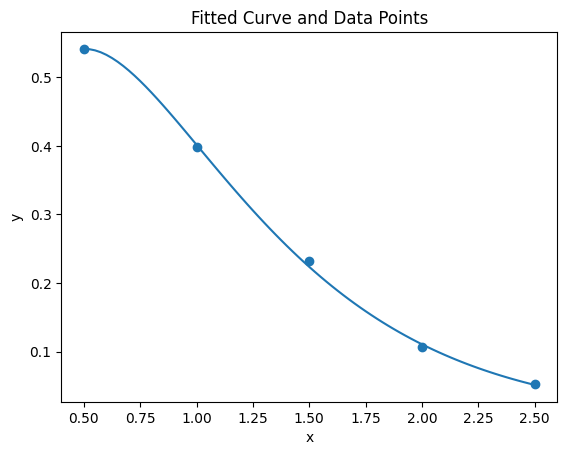

Sum of squared errors: 0.00010788688412570244


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Original data
x_data = np.array([0.5,1.0,1.5,2.0,2.5], dtype=float)
y_data = np.array([0.541,0.398,0.232,0.106,0.052], dtype=float)

# Transform for linear regression
Y = np.log(y_data / x_data)
X = x_data.copy()

# Linear regression
def linear_regression(x, y):
    n = len(x)
    sum_x = sum(x)
    sum_y = sum(y)
    sum_xx = sum(xi ** 2 for xi in x)
    sum_xy = sum(x[i] * y[i] for i in range(n))

    denominator = n * sum_xx - sum_x ** 2

    m = (n * sum_xy - sum_x * sum_y) / denominator
    b = (sum_y - m * sum_x) / n

    return m, b

b, ln_a = linear_regression(X, Y)
a = np.exp(ln_a)
print(f'a = {a}')
print(f'b = {b}')
# Generate x values
x_vals = np.arange(0.5, 2.5 + 0.025, 0.025)

# Compute y values
y_vals = a * x_vals * np.exp(b * x_vals)

# Plot
plt.figure()
plt.plot(x_vals, y_vals)
plt.scatter(x_data, y_data)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Fitted Curve and Data Points")
plt.show()

SSE = 0

for i in range(len(x_data)):
    y_pred = a * x_data[i] * np.exp(b * x_data[i])   # model prediction
    error = y_data[i] - y_pred                  # actual - predicted
    SSE += error**2

print("Sum of squared errors:", SSE)

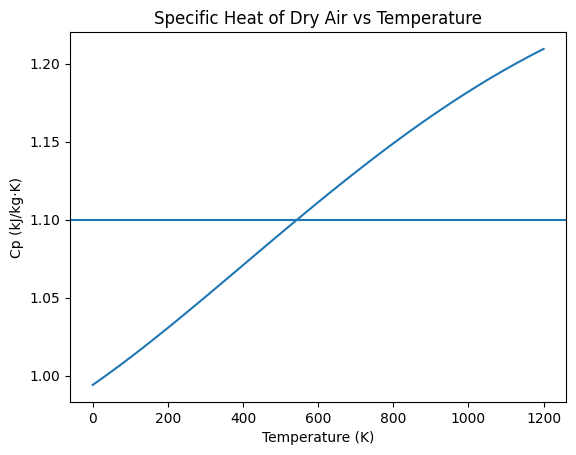

544.091796875


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import math
from numpy import sign

T = np.arange(0, 1200 + 10, 10)

def Cp(T):
    return (0.99403
      + 1.671e-4 * T
      + 9.7215e-8 * T**2
      - 9.5838e-11 * T**3
      + 1.9520e-14 * T**4)

# Plot — call the function to get the array
plt.figure()
plt.plot(T, Cp(T))
plt.axhline(1.10)
plt.xlabel("Temperature (K)")
plt.ylabel("Cp (kJ/kg·K)")
plt.title("Specific Heat of Dry Air vs Temperature")
plt.show()

def bisection(f, x1, x2, switch=1, tol=1.0e-9):
    f1 = f(x1)
    if f1 == 0.0: return x1
    f2 = f(x2)
    if f2 == 0.0: return x2
    if sign(f1) == sign(f2):
        raise ValueError('Root is not bracketed')
    n = int(math.ceil(math.log(abs(x2 - x1) / tol) / math.log(2.0)))
    for i in range(n):
        x3 = 0.5 * (x1 + x2); f3 = f(x3)
        if (switch == 1) and (abs(f3) > abs(f1)) and (abs(f3) > abs(f2)):
            return None
        if f3 == 0.0: return x3
        if sign(f2) != sign(f3):
            x1 = x3; f1 = f3
        else:
            x2 = x3; f2 = f3
    return (x1 + x2) / 2.0

target = 1.10
print(bisection(lambda T: Cp(T) - target, 500, 600, 1, 0.1))